# Module 3b: Dimension Reduction using PCA on Image data
Charles Pang, PSUPR September 2023 <br><br>


In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA, IncrementalPCA
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

## 1. Read in the MNIST image dataset of Handwritten digits

In [6]:
# Download the mnist dataset - consist of two objects
# MNIST database has 70,000 images
# 1. data = 784 pixels, values range [0..255]
# 2. target = values range [0..9]

digits = fetch_openml("mnist_784")
print("Done Fetching!")

Done Fetching!


In [5]:
# Get some basic info
print(digits.data.shape)
print(digits.target.shape)
np.unique(digits.target) # show the unique labels
#digits.data.describe()

(70000, 784)
(70000,)


array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype=object)

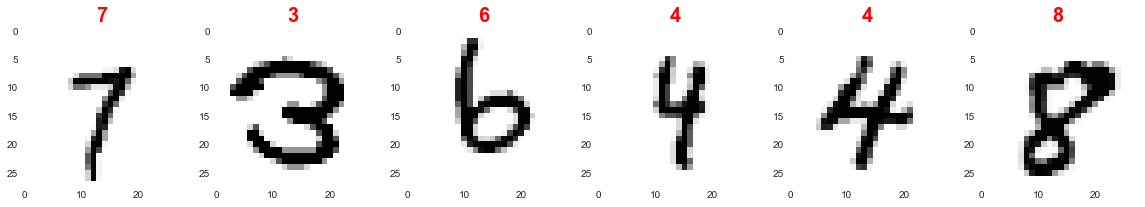

In [20]:
# Display some random sample images
import random
rdm = 6
randomlist = random.sample(range(1,70000 ), rdm)

plt.style.use('seaborn-dark')
plt.figure(figsize=(20, 4));

c = 1
for i in randomlist:
    plt.subplot(1, rdm, c);
    plt.imshow(digits.data.values[i].reshape(28,28));
    plt.title(digits.target[i], fontsize = 20, fontweight='bold', color ='red');
    c = c +1
plt.show()

## 2. Perform PCA on the Images

In [21]:
pca = PCA().fit(digits.data)
print('Done PCA!')

Done PCA!


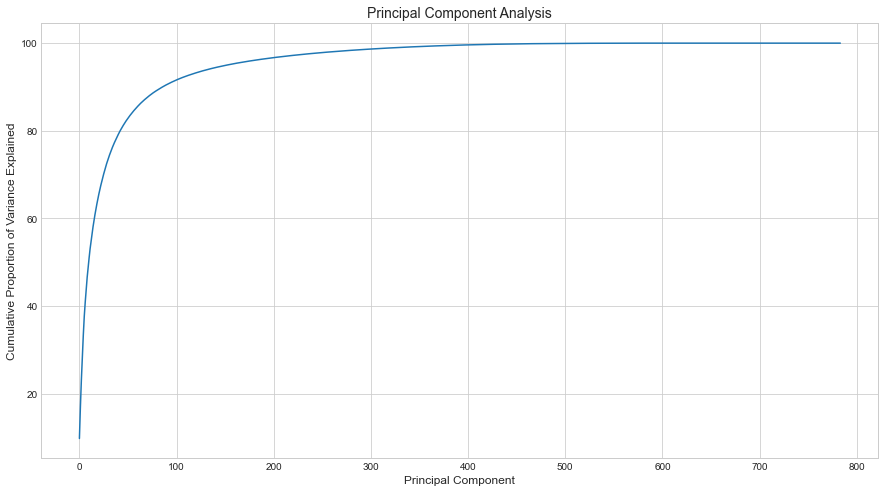

In [22]:
# pareto chart
var_expln = np.round(pca.explained_variance_ratio_ * 100,decimals=3)
cumulative_var = np.cumsum(var_expln)

plt.style.use('seaborn-whitegrid')
plt.figure(figsize=(15, 8))
plt.plot(cumulative_var)

plt.title('Principal Component Analysis',fontsize=14)
plt.xlabel("Principal Component",fontsize=12)
plt.ylabel("Cumulative Proportion of Variance Explained",fontsize=12)
plt.show()

### Number of components for various Variance Explained thresholds

In [23]:
print("100%:", 784," Principal components")
print("99% :", np.argmax(cumulative_var > 99) + 1," Principal components") 
print("95% :", np.argmax(cumulative_var > 95) + 1," Principal components") 
print("90% :", np.argmax(cumulative_var > 90) + 1," Principal components") 
print("85% :", np.argmax(cumulative_var > 85) + 1," Principal components")

100%: 784  Principal components
99% : 331  Principal components
95% : 154  Principal components
90% : 87  Principal components
85% : 59  Principal components


## 3. Show Original Image vs PCA reconstruction

In [24]:
# Obtain the new dataset of PC scores
digits_pca = pca.fit_transform(digits.data)

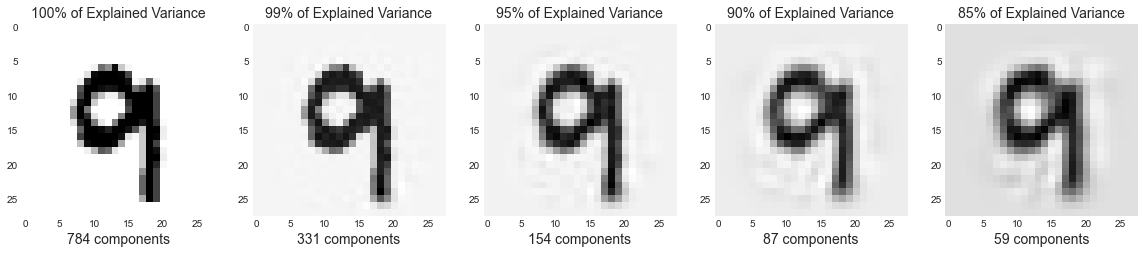

In [25]:
# Reconstruct the image using the retained PCs
rand = random.randint(1,70000) # pick image at random

plt.style.use('seaborn-dark')
plt.figure(figsize=(20, 4))

varexpl = [100, 99, 95, 90, 85]
c=1
for i in [784, 331, 154, 87, 59]:
    ipca = IncrementalPCA(n_components=i)
    image_recon = ipca.inverse_transform(ipca.fit_transform(digits.data))
    
    plt.subplot(1, 5, c)
    plt.imshow(image_recon[rand].reshape(28, 28))
    plt.xlabel(str(i)+' components', fontsize = 14)
    plt.title(str(varexpl[c-1])+'% of Explained Variance', fontsize = 14);
    c = c + 1
    
plt.show()

## 4. Use Principal Components to train LogReg Classifier

In [26]:
# Simple normalisation (/255) otherwise LogReg will fail to converge
X_train, X_test, y_train, y_test = train_test_split(digits.data/255.0, digits.target, test_size=0.3, random_state=10)

### Establish a LogReg baseline using All 784 features

In [27]:
# Run a logistic regression classifier on Principla Components
from sklearn.linear_model import LogisticRegression

logisticRegr = LogisticRegression(C=0.01, max_iter=500)
LR = logisticRegr.fit(X_train, y_train)
print("No. of features   :", X_train.shape[1])
print("Training set score:", LR.score(X_train, y_train))
print("Test set score    :", LR.score(X_test, y_test))

No. of features   : 784
Training set score: 0.9181428571428571
Test set score    : 0.9127142857142857


### Use Principal Components to train and test LogReg Classifier

In [28]:
# Run PCA to reduce dimensions
pca = PCA(.90) # Retain 95% of the variance
pca.fit(X_train)
pca.n_components_

87

In [30]:
# Use Principal Components for training
X_train_pc = pca.transform(X_train)
X_test_pc = pca.transform(X_test)

In [31]:
# Run a logistic regression classifier on transformed datasets
logisticRegr = LogisticRegression(C=0.01, max_iter=500)
LR = logisticRegr.fit(X_train_pc, y_train)

print("No. of features   :", X_train_pc.shape[1])
print("Training set score:",LR.score(X_train_pc, y_train))
print("Test set score    :",LR.score(X_test_pc, y_test))

No. of features   : 87
Training set score: 0.9128571428571428
Test set score    : 0.908047619047619


### Let's use the trained LogReg classifier to predict

In [32]:
# we will use the test set image to simulate unseeen image
rand = random.randint(1,X_test.shape[0]) # pick image at random from test set

logisticRegr.predict(X_test_pc[rand].reshape(1,-1)) # row=1, cols = unknown (-1)

array(['6'], dtype=object)

In [33]:
# the actual label is ...
y_test.iloc[rand]

'6'